<a href="https://colab.research.google.com/github/LuciusMelillo09/DataScience/blob/main/Unit8/Luci_MeliU8proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 8 Project: Writing a BARTical

**Dataset**: English Premier League / Soccer match statistics  

## Variable Selection Justification

**Response Variable**: `GoalDifference` is a direct measure of the outcome margin, making it a suitable target for a regression model that seeks to understand the factors contributing to a team's performance difference in a match.

**Predictor Variables**:
- `FTHG` / `FTAG`: Most direct determinants of GoalDifference, so I decided not to include either because it has too direct of an impact it would make the project uninteresting I think.

The variables I decided to use were both Home and Away Shots, Shots on Target, Fouls, Yellow and Red cards, and corners


In [ ]:
!pip install pymc-bart bambi preliz pymc arviz graphviz

In [ ]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import pymc_bart as pmb
import graphviz as gv
from graphviz import Digraph
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data_url = 'https://raw.githubusercontent.com/LuciusMelillo09/DataScience/refs/heads/main/Unit8/filtered_data.csv'
data2 = pd.read_csv(data_url)

# Added GoalDifference column - easiest way to see result of match
data2['GoalDifference'] = data2['FTHG'] - data2['FTAG']

data2

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,AST,HF,AF,HC,AC,HY,AY,HR,AR,GoalDifference
0,16/08/24,Man United,Fulham,1,0,H,0,0,D,R Jones,...,2,12,10,7,8,2,3,0,0,1
1,17/08/24,Ipswich,Liverpool,0,2,A,0,0,D,T Robinson,...,5,9,18,2,10,3,1,0,0,-2
2,17/08/24,Arsenal,Wolves,2,0,H,1,0,H,J Gillett,...,3,17,14,8,2,2,2,0,0,2
3,17/08/24,Everton,Brighton,0,3,A,0,1,A,S Hooper,...,5,8,8,1,5,1,1,1,0,-3
4,17/08/24,Newcastle,Southampton,1,0,H,1,0,H,C Pawson,...,4,15,16,3,12,2,4,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,25/05/25,Newcastle,Everton,0,1,A,0,0,D,T Harrington,...,6,12,9,12,3,1,4,0,0,-1
376,25/05/25,Nott'm Forest,Chelsea,0,1,A,0,0,D,A Taylor,...,2,10,11,7,4,2,2,0,0,-1
377,25/05/25,Southampton,Arsenal,1,2,A,0,1,A,D Bond,...,8,7,8,5,8,0,0,0,0,-1
378,25/05/25,Tottenham,Brighton,1,4,A,1,0,H,R Jones,...,8,13,8,2,11,3,1,0,0,-3


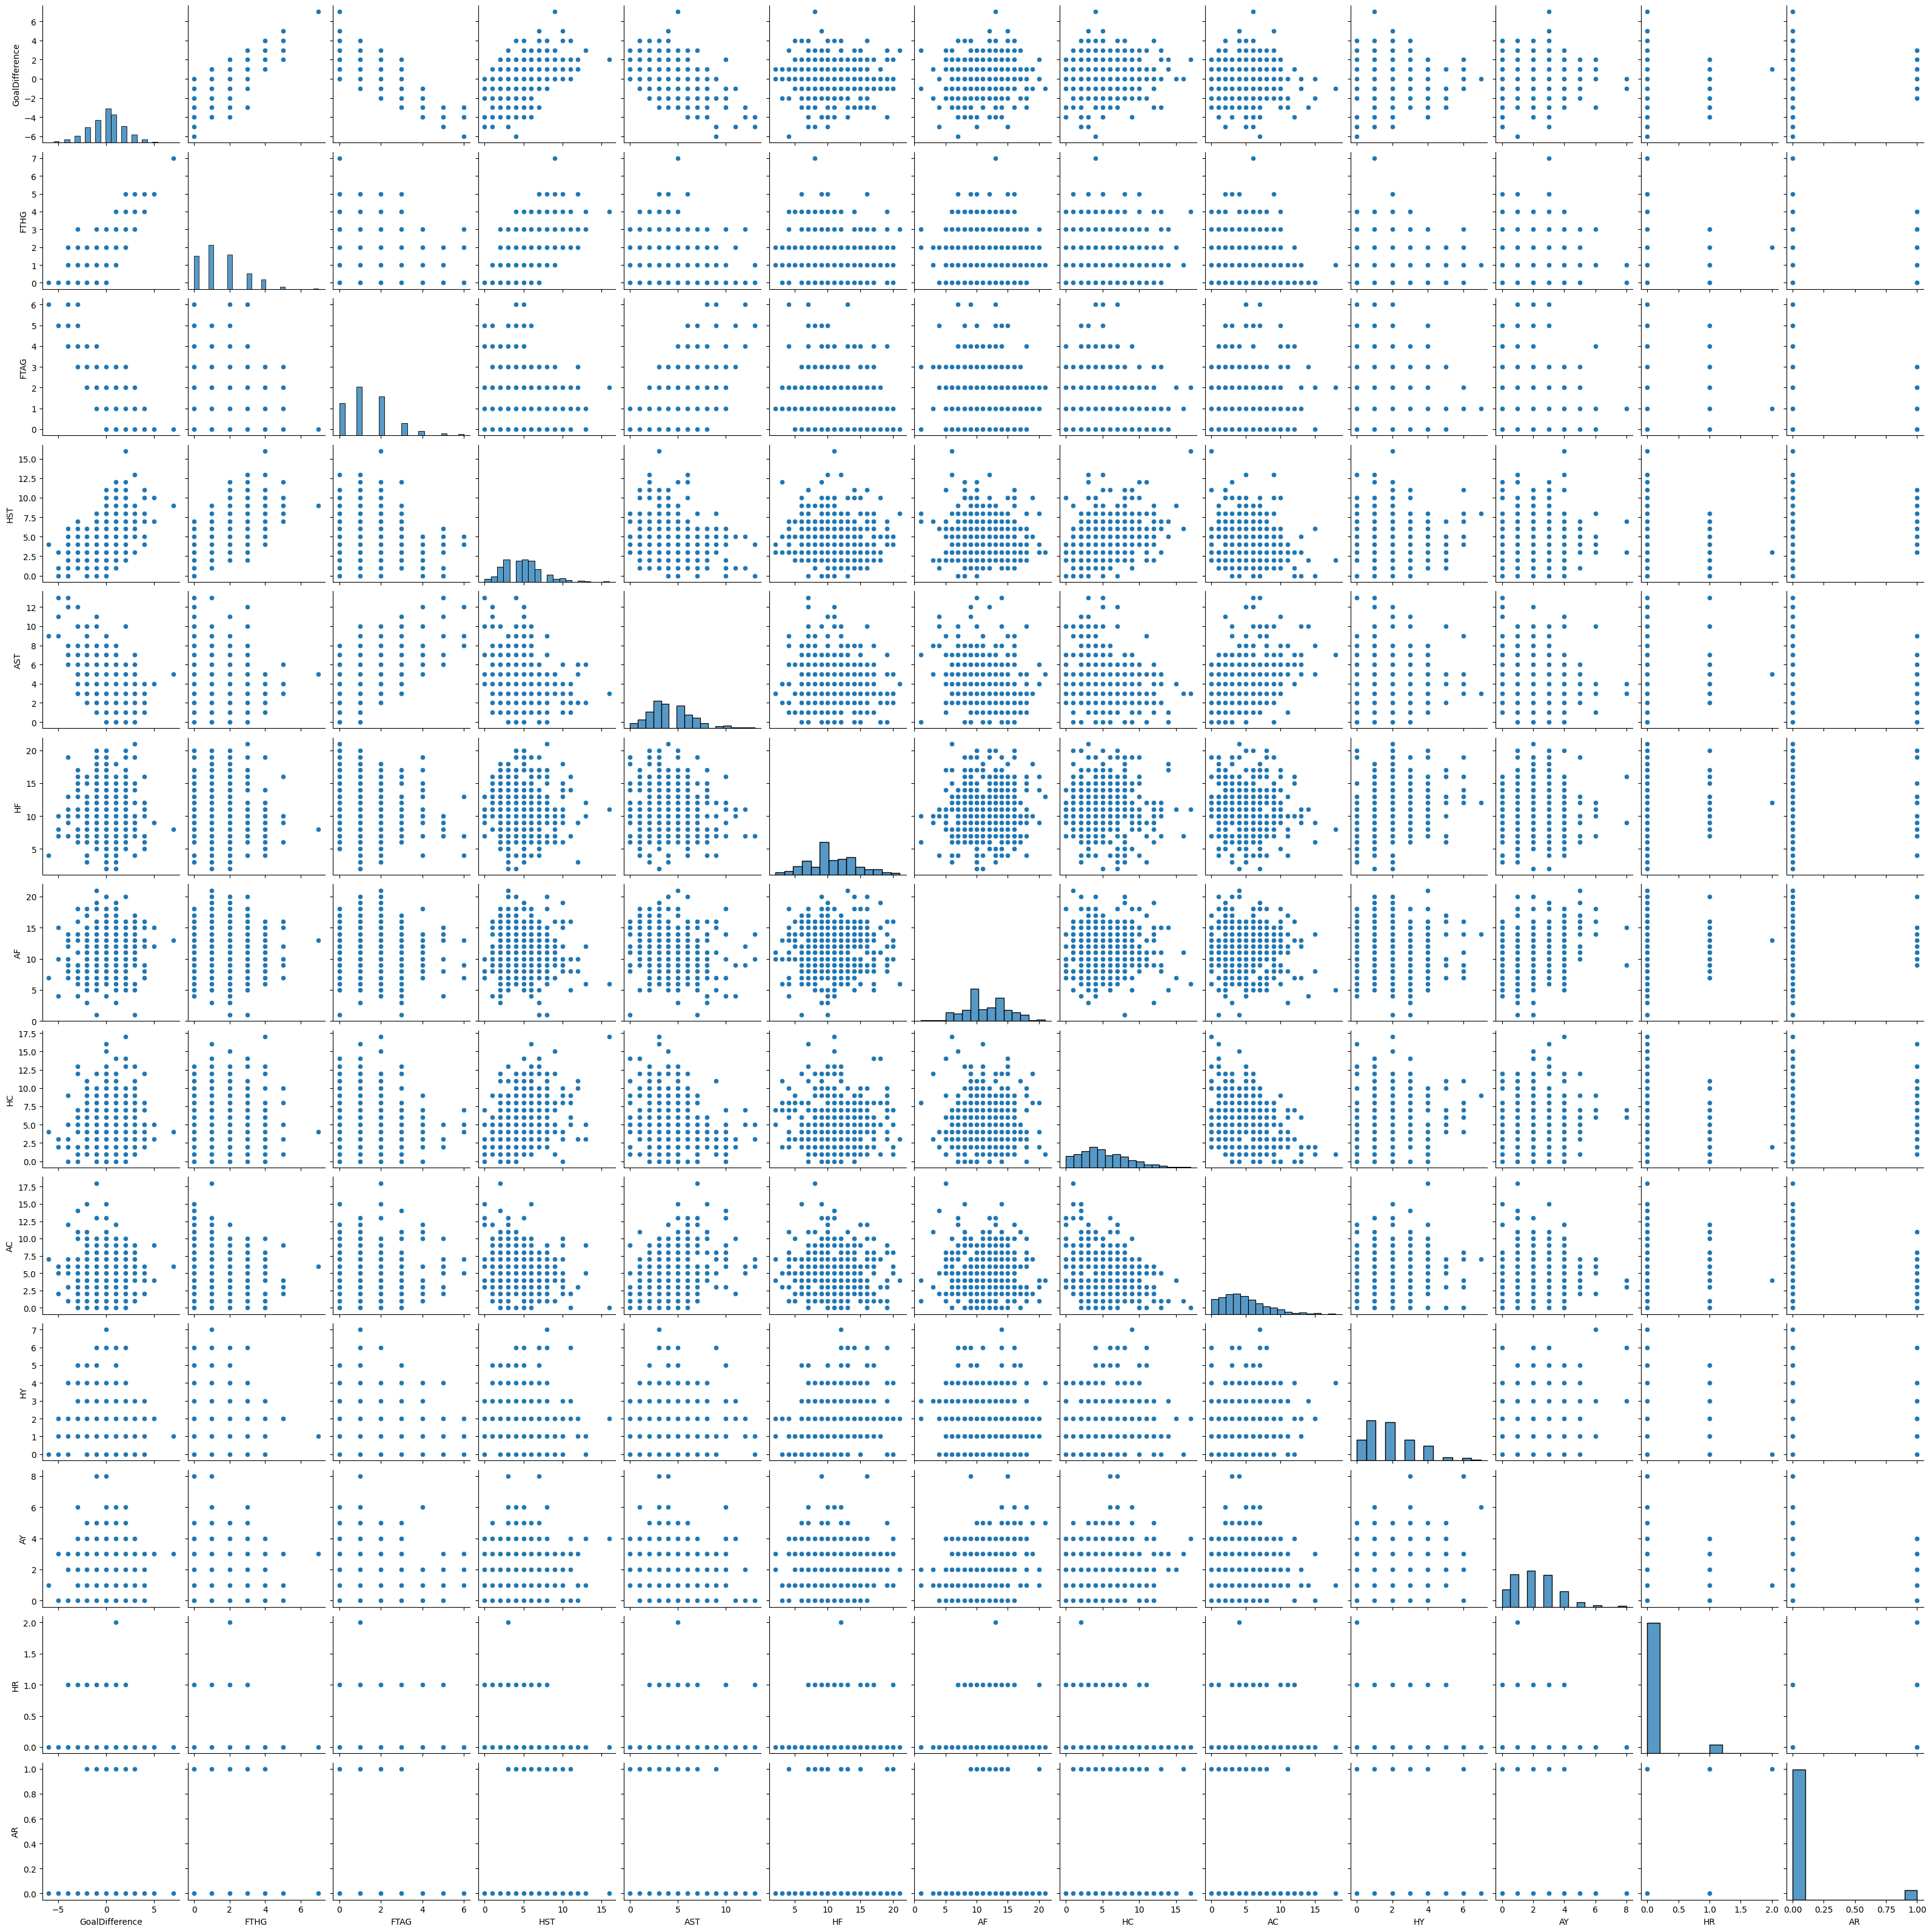

In [ ]:
selected_variables = ['GoalDifference', 'FTHG', 'FTAG', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR']
sns.pairplot(data2[selected_variables])

## Causal Diagram



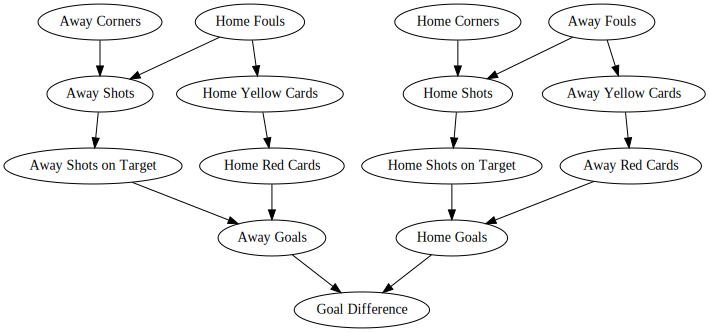

In [ ]:
from graphviz import Digraph

dag = Digraph(comment='Causal Diagram')
dag.node('HC',  'Home Corners')
dag.node('HS',  'Home Shots')
dag.node('HST', 'Home Shots on Target')
dag.node('HG',  'Home Goals')
dag.node('HF',  'Home Fouls')
dag.node('HY',  'Home Yellow Cards')
dag.node('HR',  'Home Red Cards')
dag.node('AC',  'Away Corners')
dag.node('AS',  'Away Shots')
dag.node('AST', 'Away Shots on Target')
dag.node('AG',  'Away Goals')
dag.node('AF',  'Away Fouls')
dag.node('AY',  'Away Yellow Cards')
dag.node('AR',  'Away Red Cards')
dag.node('GD',  'Goal Difference')

dag.edge('HC',  'HS')
dag.edge('HS',  'HST')
dag.edge('HST', 'HG')
dag.edge('HG',  'GD')
dag.edge('AC',  'AS')
dag.edge('AS',  'AST')
dag.edge('AST', 'AG')
dag.edge('AG',  'GD')
dag.edge('HF', 'AS')
dag.edge('AF', 'HS')
dag.edge('HY', 'HR')
dag.edge('AY', 'AR')
dag.edge('HR', 'AG')
dag.edge('AR', 'HG')
dag.edge('HF', 'HY')
dag.edge('AF', 'AY')

display(dag)

##BART Model



In [ ]:
predictor_variables = ['HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR']
X = data2[predictor_variables].to_numpy()
y = data2['GoalDifference'].to_numpy()

In [ ]:
with pm.Model() as bart_model:
    mu = pmb.BART('mu', X=X, Y=y, m=50)

    sigma = pm.HalfNormal('sigma', sigma=2)

    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

    idata = pm.sample(
        draws=1000,
        tune=500,
        chains=2,
        random_seed=42,
    )

In [ ]:
with bart_model:
    ppc = pm.sample_posterior_predictive(idata, random_seed=42)
idata.extend(ppc)

##Variable Importance



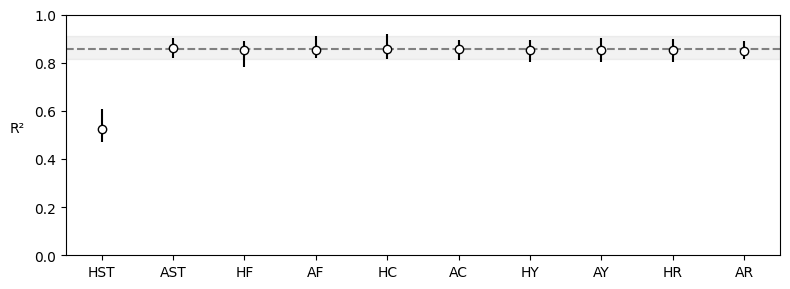

In [ ]:
vi_soccer = pmb.compute_variable_importance(idata, mu, X)
pmb.plot_variable_importance(vi_soccer, labels=predictor_variables)
plt.tight_layout()
plt.show()

##Partial Dependence Plots

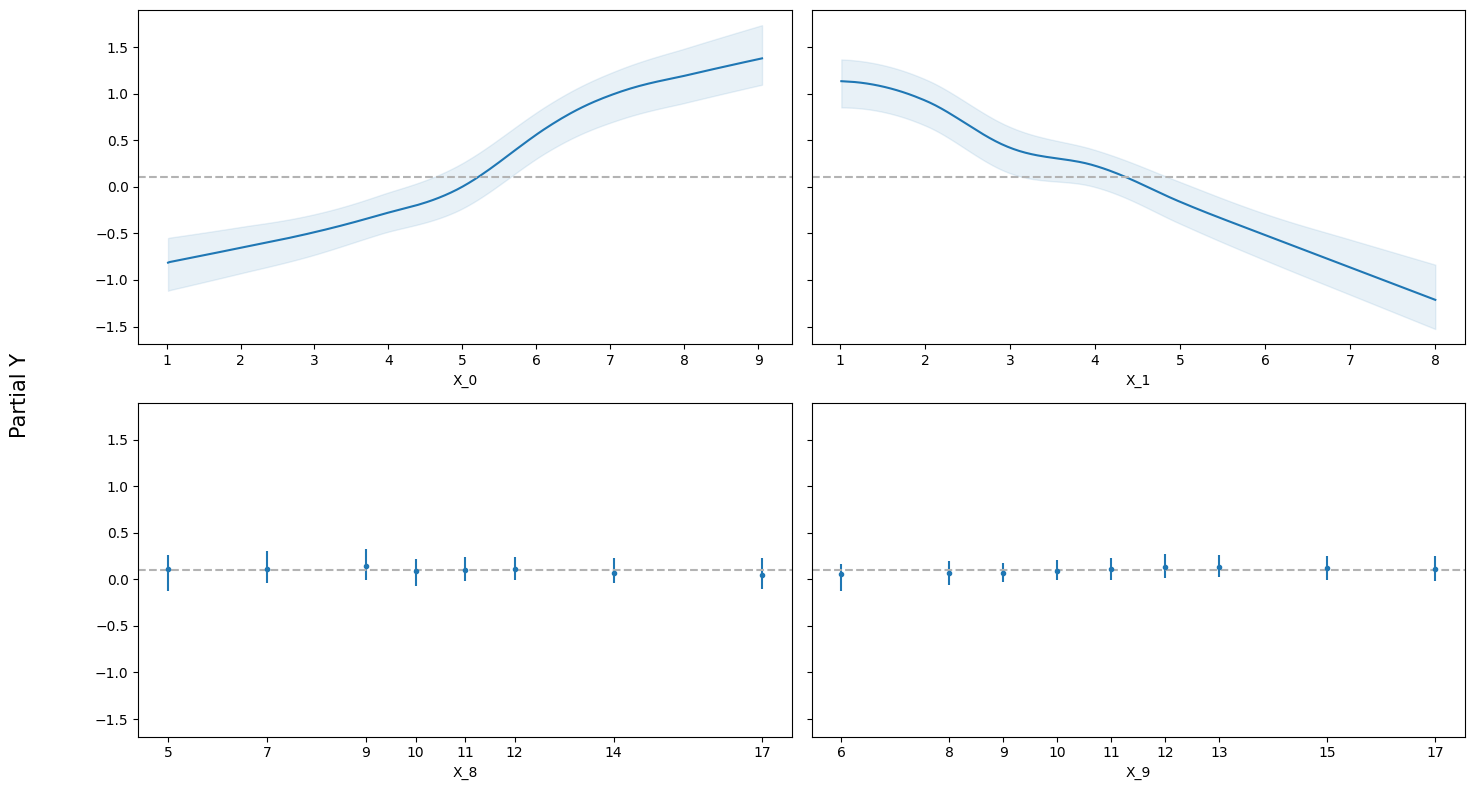

In [ ]:
key_labels  = ['HST', 'AST', 'HR', 'AR']
key_indices = [predictor_variables.index(c) for c in key_labels]

pmb.plot_pdp(mu, X, y,
             var_idx=key_indices,
             var_discrete=[2, 3],
             grid=(2, 2),
             figsize=(14, 8))
plt.tight_layout()
plt.show()

## Summary & Conclusions

Among the indirect predictors, `HST` is the most informative. I'm confused why `AST` isn't more important, maybe something went wrong in the model because I think that `AST` should be roughly as important as `HST`. Red cards (`HR`, `AR`) show notable importance, makes sense with having less players
Fouls, corners, and yellow cards have very slight contributions.


